In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (downloaded from Kaggle)
df = pd.read_csv('heart_disease_uci.csv')

print("Look at the first 5 patients")
print(df.head())

print("Check for missing values and column data types")
print(df.info())
print("Number of missing values")
print(df.isna().sum())

Look at the first 5 patients
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4      

In [164]:
# Handling missing values

for col in ['slope', 'fbs', 'exang', 'restecg']:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['trestbps', 'thalch', 'chol', 'oldpeak']:
    df[col] = df[col].fillna(df[col].median())

/var/folders/ds/dw3yxr3n17zcdr5tkgbclc5w0000gn/T/ipykernel_68420/2141657958.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [165]:
# Make missing values in 'ca' and 'thal' a separate category (because in clinical datasets, data is often missing not at random) 
df['thal'] = df['thal'].fillna('Unknown')
df['ca'] = df['ca'].fillna(-1)

print("Number of missing values: now")
# Check if every value is filled
print(df.isna().sum())

Number of missing values: now
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [166]:
# Dropping id

df = df.drop(columns = ['id'])

In [167]:
# Make 'sex' column binary

df['sex'] = pd.get_dummies(df['sex'], drop_first = True, dtype=int)
df['sex']

0      1
1      1
2      1
3      1
4      0
      ..
915    0
916    1
917    1
918    1
919    1
Name: sex, Length: 920, dtype: int64

In [168]:
# Turn num column into a binary classificiation problem: 0 = no heart disease, 1 = heart disease
# Convert 1, 2, 3, 4 into 1
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns = ['num'])
print(df['target'])

# Convert fbs column into binary classification problem: 0 = fasting blood sugar <= 120 mg/dl, 1 = fasting blood sugar > 120 mg/dl)
df['fbs'] = (df['fbs'] == True).astype(int)
print(df['fbs'])

# One-hot encode the 'thal' column
thal_dummies = pd.get_dummies(df['thal'], prefix='thal', dtype=int)

# Join the new columns back to the dataframe and drop the original 'thal'
df = pd.concat([df, thal_dummies], axis=1).drop(columns=['thal'])

0      0
1      1
2      1
3      0
4      0
      ..
915    1
916    0
917    1
918    0
919    1
Name: target, Length: 920, dtype: int64
0      1
1      0
2      0
3      0
4      0
      ..
915    1
916    0
917    1
918    1
919    0
Name: fbs, Length: 920, dtype: int64


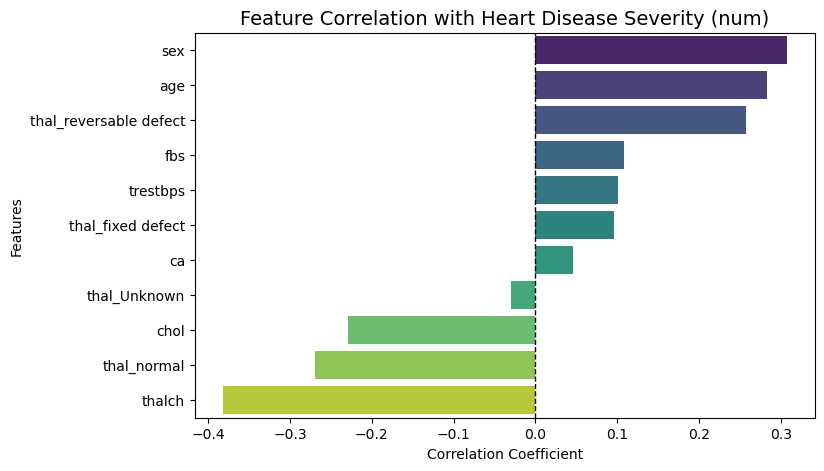

In [169]:
# Calculate correlation of all features with just 'num'
features = ["age", "sex", "trestbps", "chol", "fbs", "thalch", "target", "ca", "thal_fixed defect", "thal_normal", "thal_reversable defect", "thal_Unknown"]
target_corr = df[features].corr()['target'].drop('target').sort_values(ascending=False)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette="viridis")
plt.title("Feature Correlation with Heart Disease Severity (num)", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(0, color='black', linestyle='--', linewidth=1) # Adds a center line at 0
plt.show()

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features.remove("target")
features.remove("thal_Unknown")
features.remove("thal_fixed defect")
# features.remove("ca")

# features.remove("thal_normal")
# features.remove("thal_reversable defect")
X = df[features]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [171]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
accuracy = rf_model.score(X_test_scaled, y_test)
print(f"Model Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        75
           1       0.84      0.80      0.82       109

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



In [172]:
# Notice: class 1 - recall score is only 0.78. To make this better, let's manually adjust the prediction threshold
# 1. Get the raw probabilities for the positive class (1) instead of hard predictions
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Lower the threshold to 0.35 (If probability >= 35%, flag as heart disease)
y_pred_adjusted = (y_prob >= 0.35).astype(int)

# 3. Check the new scores
print("--- Adjusted Threshold (0.35) ---")
print(classification_report(y_test, y_pred_adjusted))

--- Adjusted Threshold (0.35) ---
              precision    recall  f1-score   support

           0       0.80      0.64      0.71        75
           1       0.78      0.89      0.83       109

    accuracy                           0.79       184
   macro avg       0.79      0.76      0.77       184
weighted avg       0.79      0.79      0.78       184



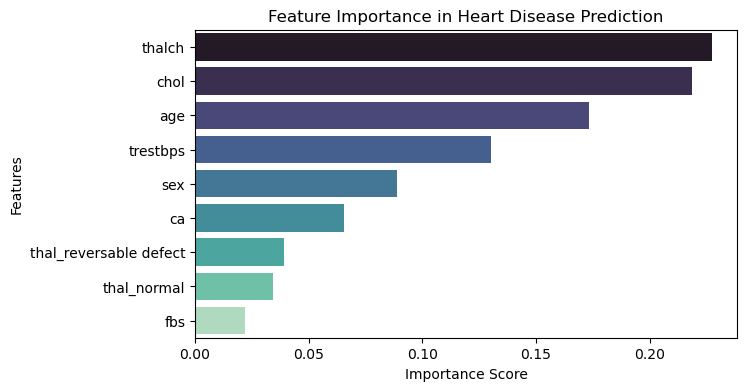

In [173]:
# Grab feature importances from trained Random Forest
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot it
plt.figure(figsize=(7, 4))
sns.barplot(x=feat_importances.values, y=feat_importances.index, hue=feat_importances.index, palette="mako", legend=False)
plt.title("Feature Importance in Heart Disease Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()